# Assignment 2 — Describe Your Data
**Course:** AIM 402 Statistics for Data Analysis Using Python  
**Dataset:** IBM Telco Customer Churn (Kaggle, BlastChar, DbCL v1.0), 7,043 rows × 21 columns — same dataset as Assignment 1  
**Numerical variables analysed:** `tenure` (months) and `MonthlyCharges` (USD)  
**Categorical variable for the comparison:** `Contract` (Month-to-month / One year / Two year)

> Cells marked **✍ WRITE** are for your own interpretation. Run the code first, read the output, then write in your own words.

In [1]:
# 0. Imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Change this path to wherever your Kaggle CSV is saved
CSV_PATH = "Telco-Customer-Churn.csv"

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)

# The two numerical variables for this assignment
VAR1 = "tenure"
VAR2 = "MonthlyCharges"
x1 = df[VAR1]
x2 = df[VAR2]

# Both columns should have no missing values; confirm it
print("Missing in", VAR1, ":", x1.isna().sum())
print("Missing in", VAR2, ":", x2.isna().sum())

Shape: (7043, 21)
Missing in tenure : 0
Missing in MonthlyCharges : 0


## Part 1 — Centre, shape and spread, and the skewness check

In [2]:
# 1a. Mean, median, standard deviation, IQR for both variables
def describe_one(series):
    # series.std() uses n - 1 by default (sample standard deviation)
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return {
        "n": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "std (n-1)": series.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "min": series.min(),
        "max": series.max(),
        "skew": series.skew(),
    }

summary = pd.DataFrame({VAR1: describe_one(x1), VAR2: describe_one(x2)})
summary.round(3)

,tenure,MonthlyCharges
n,7043.000,7043.000
mean,32.371,64.762
median,29.000,70.350
std (n-1),24.559,30.090
Q1,9.000,35.500
Q3,55.000,89.850
IQR,46.000,54.350
min,0.000,18.250
max,72.000,118.750
skew,0.240,-0.221


In [3]:
# 1b. Does the sign of the skewness agree with the mean - median gap?
for name, s in [(VAR1, x1), (VAR2, x2)]:
    gap = s.mean() - s.median()
    sk = s.skew()
    print(f"{name}: mean - median = {gap:.3f}, skew = {sk:.3f}")
    if gap > 0 and sk > 0:
        print("   Agree: mean above median and positive skew (right-skewed).")
    elif gap < 0 and sk < 0:
        print("   Agree: mean below median and negative skew (left-skewed).")
    elif abs(gap) < 0.05 * s.std() and abs(sk) < 0.2:
        print("   Both near zero: approximately symmetric.")
    else:
        print("   DISAGREE - investigate (multimodality, outliers, ties, rounding).")

tenure: mean - median = 3.371, skew = 0.240
   Agree: mean above median and positive skew (right-skewed).
MonthlyCharges: mean - median = -5.588, skew = -0.221
   Agree: mean below median and negative skew (left-skewed).


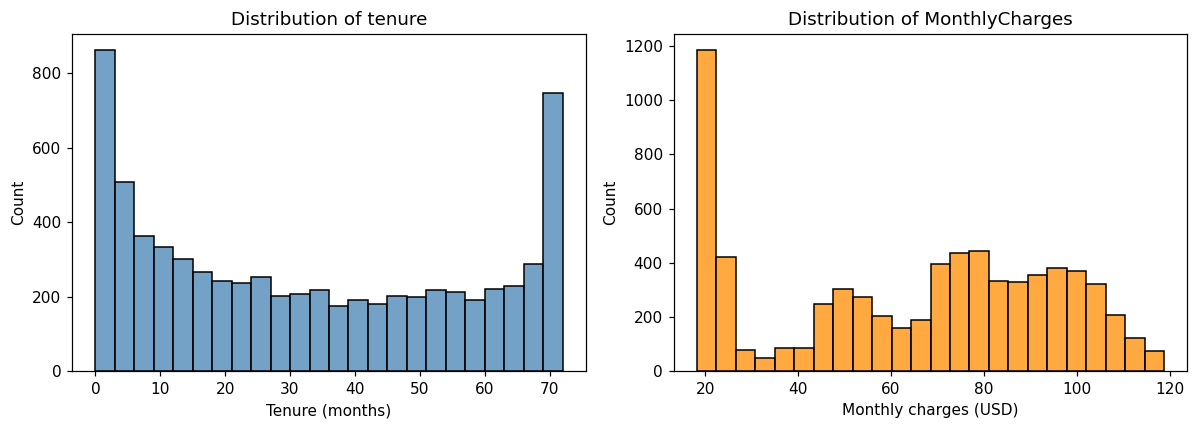

In [4]:
# Quick look at the shape (needed for the three-clause description)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(x1, bins=24, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of tenure")
axes[0].set_xlabel("Tenure (months)")
sns.histplot(x2, bins=24, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of MonthlyCharges")
axes[1].set_xlabel("Monthly charges (USD)")
plt.tight_layout()
plt.show()

**✍ WRITE — three clauses per variable (centre, shape, spread)**

- `tenure`: *centre* — median 29 months, mean 32.37 months; *shape* — mildly right-skewed, with a spike of new customers at 0–1 months and another spike at the 72-month ceiling; *spread* — wide (SD = 24.56 months, IQR = 46 months, range 0 to 72).
- `MonthlyCharges`: *centre* — median $70.35, mean $64.76; *shape* — mildly left-skewed and bimodal (a tall peak near $20 and a broad hump from about $70 to $100); *spread* — wide (SD = $30.09, IQR = $54.35, range $18.25 to $118.75).

**✍ WRITE — skewness check:** For tenure, `.skew()` = 0.240 and mean − median = 3.371; both signs are positive, so they agree on mild right skew. For MonthlyCharges, `.skew()` = −0.221 and mean − median = −5.588; both signs are negative, so they agree on mild left skew. The signs do not disagree. These are only rules of thumb: MonthlyCharges has two peaks, which a single skew number cannot describe.

## Part 2 — Verify the standard deviation by hand on a 10-row subset

In [5]:
# 2. Manual standard deviation on the first 10 rows (matches your handwritten worksheet)
def manual_std(values):
    n = len(values)
    mean = sum(values) / n
    # Step 1: deviation of each value from the mean, then squared
    squared_devs = []
    for v in values:
        d = v - mean
        squared_devs.append(d * d)
    # Step 2: sum of squared deviations
    ss = sum(squared_devs)
    # Step 3: sample variance and standard deviation (divide by n - 1)
    variance = ss / (n - 1)
    sd = variance ** 0.5
    return mean, squared_devs, ss, variance, sd

for name in [VAR1, VAR2]:
    subset = df[name].head(10).tolist()
    mean, sq, ss, var, sd = manual_std(subset)
    print("Variable:", name)
    print("Values:", subset)
    print(f"Mean = {mean:.4f}")
    print("Squared deviations:", [round(v, 4) for v in sq])
    print(f"Sum of squared deviations = {ss:.4f}")
    print(f"Variance = SS/(n-1) = {var:.4f}")
    print(f"Manual std = {sd:.6f}")
    print(f"pandas .std() = {pd.Series(subset).std():.6f}")
    print("Match:", np.isclose(sd, pd.Series(subset).std()))
    print()

Variable: tenure
Values: [1, 34, 2, 45, 2, 8, 22, 10, 28, 62]
Mean = 21.4000
Squared deviations: [416.16, 158.76, 376.36, 556.96, 376.36, 179.56, 0.36, 129.96, 43.56, 1648.36]
Sum of squared deviations = 3886.4000
Variance = SS/(n-1) = 431.8222
Manual std = 20.780333
pandas .std() = 20.780333
Match: True

Variable: MonthlyCharges
Values: [29.85, 56.95, 53.85, 42.3, 70.7, 99.65, 89.1, 29.75, 104.8, 56.15]
Mean = 63.3100
Squared deviations: [1119.5716, 40.4496, 89.4916, 441.4201, 54.6121, 1320.5956, 665.1241, 1126.2736, 1721.4201, 51.2656]
Sum of squared deviations = 6630.2240
Variance = SS/(n-1) = 736.6916
Manual std = 27.142062
pandas .std() = 27.142062
Match: True



**✍ WRITE:** On the first 10 rows, the hand-calculated sample SD matched pandas `.std()` for both variables (tenure 20.7803; MonthlyCharges 27.1421). The match shows that `.std()` divides by n − 1 rather than n, which is the sample (not population) standard deviation.

## Part 3 — Histogram at three bin widths, boxplot, and 1.5 × IQR fences

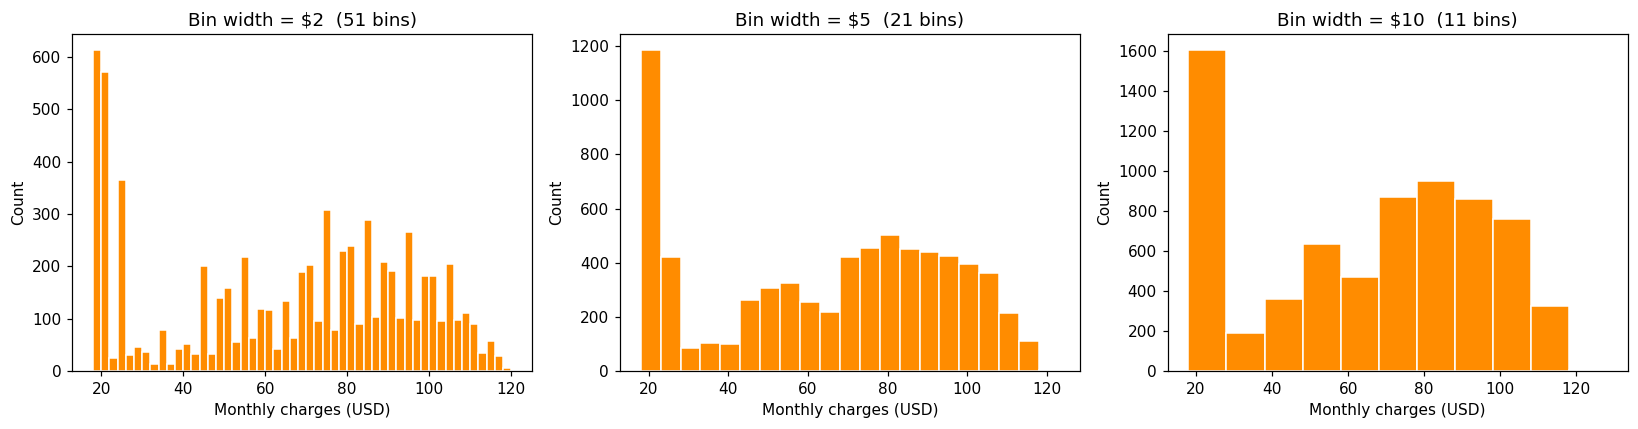

In [6]:
# 3a. Histogram of MonthlyCharges at three bin widths
data = x2.dropna()
bin_widths = [2, 5, 10]   # USD per bin
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, w in zip(axes, bin_widths):
    edges = np.arange(np.floor(data.min()), data.max() + w, w)
    ax.hist(data, bins=edges, color="darkorange", edgecolor="white")
    ax.set_title(f"Bin width = ${w}  ({len(edges) - 1} bins)")
    ax.set_xlabel("Monthly charges (USD)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

**✍ WRITE:** I would report the $5 bin width (21 bins). At $2 the histogram is jagged, so some of the up-and-down movement is noise. At $10 there are only 11 bars and the sharp low-charge peak is merged into one wide first bar, hiding that those customers sit near the $18.25 minimum (phone-only / no-internet plans). $5 keeps that low peak and the $70–$100 hump without the noise (Bruce et al., 2020).

tenure: Q1=9.0, Q3=55.0, IQR=46.0, lower fence=-60.0, upper fence=124.0
Number of rows outside the fences: 0
No rows fall outside the fences. Most extreme values:
  Minimum: 0  Maximum: 72

MonthlyCharges: Q1=35.5, Q3=89.85, IQR=54.349999999999994, lower fence=-46.02499999999999, upper fence=171.375
Number of rows outside the fences: 0
No rows fall outside the fences. Most extreme values:
  Minimum: 18.25  Maximum: 118.75



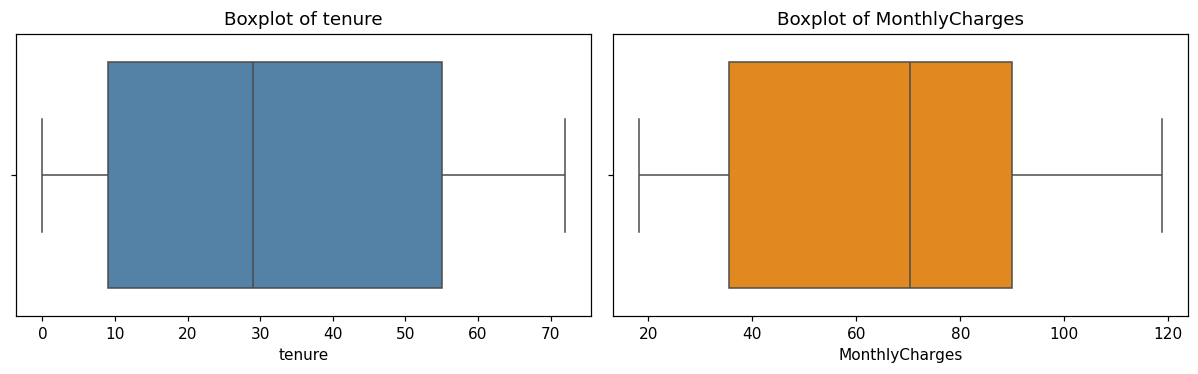

In [7]:
# 3b. Boxplot and 1.5 x IQR fences
def iqr_fences(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return q1, q3, iqr, lower, upper

for name in [VAR1, VAR2]:
    s = df[name]
    q1, q3, iqr, lower, upper = iqr_fences(s)
    print(f"{name}: Q1={q1}, Q3={q3}, IQR={iqr}, lower fence={lower}, upper fence={upper}")
    outliers = df[(s < lower) | (s > upper)]
    print("Number of rows outside the fences:", len(outliers))
    if len(outliers) > 0:
        display(outliers[[VAR1, VAR2, "Contract", "Churn"]].head(30))
    else:
        print("No rows fall outside the fences. Most extreme values:")
        print("  Minimum:", s.min(), " Maximum:", s.max())
    print()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(x=x1, ax=axes[0], color="steelblue")
axes[0].set_title("Boxplot of tenure")
sns.boxplot(x=x2, ax=axes[1], color="darkorange")
axes[1].set_title("Boxplot of MonthlyCharges")
plt.tight_layout()
plt.show()

**✍ WRITE — outlier judgement.** Neither `tenure` nor `MonthlyCharges` has any 1.5 × IQR outliers; every value sits inside the fences. That is a finding, not a missing step: both variables are bounded (tenure by 0 and 72 months; charges by plan prices) and both IQRs are wide, so the fences fall outside the observed range. The 11 rows with tenure = 0 have blank `TotalCharges` and look like new sign-ups that have not been billed yet (*legitimate observation*). Tenure = 72 is the ceiling of the collection window (*legitimate extreme*, not the true lifetime of every long customer). The maximum monthly charge of $118.75 is a fibre-optic two-year customer and is consistent with a fully bundled plan (*legitimate extreme*). A billing error cannot be ruled out without the original invoices, but the other fields do not contradict these values.

## Part 4 — z scores and the 68 / 95 / 99.7 rule

In [8]:
# 4. z scores and empirical-rule comparison
def z_summary(series):
    z = (series - series.mean()) / series.std()   # sample std (n - 1)
    within1 = (z.abs() <= 1).mean() * 100
    within2 = (z.abs() <= 2).mean() * 100
    within3 = (z.abs() <= 3).mean() * 100
    return z, within1, within2, within3

rows = []
for name in [VAR1, VAR2]:
    z, w1, w2, w3 = z_summary(df[name])
    df[name + "_z"] = z
    rows.append([name, w1, w2, w3, z.min(), z.max()])

rule = pd.DataFrame(rows, columns=["variable", "% within 1 SD", "% within 2 SD",
                                   "% within 3 SD", "min z", "max z"])
rule.loc[len(rule)] = ["Normal benchmark", 68.0, 95.0, 99.7, np.nan, np.nan]
rule.round(2)

,variable,% within 1 SD,% within 2 SD,% within 3 SD,min z,max z
0,tenure,53.33,100.0,100.0,-1.32,1.61
1,MonthlyCharges,56.84,100.0,100.0,-1.55,1.79
2,Normal benchmark,68.00,95.0,99.7,NaN,NaN


      tenure_z  MonthlyCharges_z
mean      -0.0              -0.0
std        1.0               1.0


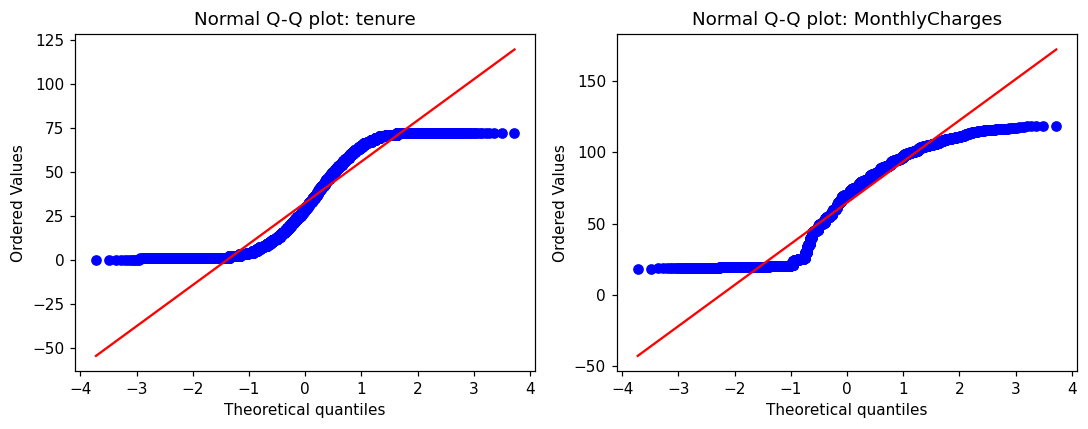

In [9]:
# Check that standardising gives mean 0 and std 1
print(df[[VAR1 + "_z", VAR2 + "_z"]].agg(["mean", "std"]).round(6))

# Q-Q style visual check against the normal curve
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(df[VAR1], dist="norm", plot=axes[0])
axes[0].set_title("Normal Q-Q plot: tenure")
stats.probplot(df[VAR2], dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot: MonthlyCharges")
plt.tight_layout()
plt.show()

**✍ WRITE:** Neither variable follows the 68 / 95 / 99.7 rule. About 53.3% of tenure values and 56.8% of MonthlyCharges values fall within one SD (well under 68%), while 100% of both fall within two SD (above 95%). Max |z| is only about 1.61 for tenure and 1.79 for MonthlyCharges, so there are no long tails. The tenure histogram is fairly flat with spikes at both ends, MonthlyCharges is bimodal, and both Q–Q plots bend off the straight line. Neither variable is approximately normal.

**✍ WRITE (one sentence) — why z scores give a common scale:** A z-score writes each value as how many of its own standard deviations it sits from its own mean, so tenure (months) and MonthlyCharges (dollars) both end up with mean 0, SD 1, and no units, and can be compared on one scale.

## Part 5 — Comparative display: MonthlyCharges across Contract

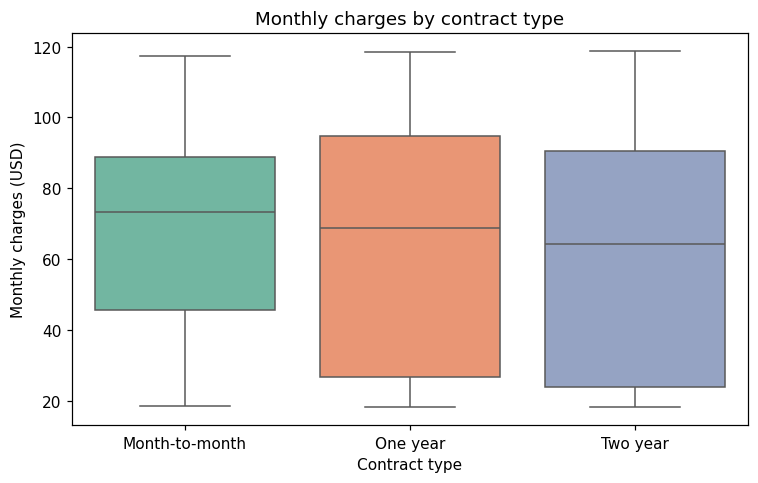

,n,mean,median,std,Q1,Q3,IQR
Contract,,,,,,,
Month-to-month,3875,66.40,73.25,26.93,45.85,88.88,43.02
One year,1473,65.05,68.75,31.84,26.90,94.80,67.90
Two year,1695,60.77,64.35,34.68,24.02,90.45,66.43


In [10]:
# 5. Side-by-side boxplots of MonthlyCharges by Contract
order = ["Month-to-month", "One year", "Two year"]
plt.figure(figsize=(7, 4.5))
sns.boxplot(
    data=df, x="Contract", y="MonthlyCharges", hue="Contract",
    order=order, palette="Set2", legend=False
)
plt.title("Monthly charges by contract type")
plt.xlabel("Contract type")
plt.ylabel("Monthly charges (USD)")
plt.tight_layout()
plt.show()

# Numbers to support the description
group_stats = df.groupby("Contract")["MonthlyCharges"].agg(
    n="count", mean="mean", median="median", std="std",
    Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75))
group_stats["IQR"] = group_stats["Q3"] - group_stats["Q1"]
group_stats.loc[order].round(2)

**✍ WRITE:** The median monthly charge falls as the contract gets longer: $73.25 (month-to-month), $68.75 (one year), $64.35 (two years). Month-to-month also has the narrowest spread (IQR $43.02), while one-year and two-year contracts are wider (IQR about $66–$68). The three boxes overlap a lot, and the means differ less than the medians, so the association is modest. The plot shows an association in these data; it does not show that contract type causes the charge to differ, because customers choose both their services and their contract.

## References (APA 7th)

Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical statistics for data scientists: 50+ essential concepts using R and Python* (2nd ed.). O'Reilly Media.

Peck, R., & Olsen, C. (2025). *Introduction to statistics and data analysis* (7th ed.). Cengage Learning.

BlastChar. (n.d.). *Telco customer churn* [Data set]. Kaggle. https://www.kaggle.com/datasets/blastchar/telco-customer-churn